In [6]:
import pandas as pd

df = pd.read_excel(r'C:\Users\igorg\Documents\projects\auditory\default of credit card clients.xls')
print(df.shape)
df.head()


(30001, 25)


,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0


In [7]:
df.columns

Index(['Unnamed: 0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9',
       'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19',
       'X20', 'X21', 'X22', 'X23', 'Y'],
      dtype='object')

In [11]:
df = df.iloc[1:].reset_index(drop=True)

In [12]:
df.head()

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [13]:
column_mapping = {
    "X1": "LIMIT_BAL",
    "X2": "SEX",
    "X3": "EDUCATION",
    "X4": "MARRIAGE",
    "X5": "AGE",
    "X6": "PAY_0",
    "X7": "PAY_2",
    "X8": "PAY_3",
    "X9": "PAY_4",
    "X10": "PAY_5",
    "X11": "PAY_6",
    "X12": "BILL_AMT1",
    "X13": "BILL_AMT2",
    "X14": "BILL_AMT3",
    "X15": "BILL_AMT4",
    "X16": "BILL_AMT5",
    "X17": "BILL_AMT6",
    "X18": "PAY_AMT1",
    "X19": "PAY_AMT2",
    "X20": "PAY_AMT3",
    "X21": "PAY_AMT4",
    "X22": "PAY_AMT5",
    "X23": "PAY_AMT6",
    "Y": "DEFAULT"
}

df = df.rename(columns=column_mapping)

In [15]:
df.columns
df["DEFAULT"].value_counts(normalize=True)


DEFAULT
0    0.7788
1    0.2212
Name: proportion, dtype: float64

In [17]:
df['AGE_BIN'] = pd.cut(
    df['AGE'],
    bins = [20,30,40,50,100],
    labels=["21-29", "30-39", "40-49", "50+"],
    right=False
)

In [18]:
df["AGE_BIN"].value_counts()


AGE_BIN
30-39    11238
21-29     9618
40-49     6464
50+       2680
Name: count, dtype: int64

In [26]:
df = df.drop(columns=["Unnamed: 0"], errors="ignore")


In [27]:
cols_to_numeric = [c for c in df.columns if c != "AGE_BIN"]

df[cols_to_numeric] = df[cols_to_numeric].apply(pd.to_numeric, errors="coerce")


In [28]:
print(df.dtypes)
print("Nulos por coluna (top 10):")
print(df.isna().sum().sort_values(ascending=False).head(10))


LIMIT_BAL       int64
SEX             int64
EDUCATION       int64
MARRIAGE        int64
AGE             int64
PAY_0           int64
PAY_2           int64
PAY_3           int64
PAY_4           int64
PAY_5           int64
PAY_6           int64
BILL_AMT1       int64
BILL_AMT2       int64
BILL_AMT3       int64
BILL_AMT4       int64
BILL_AMT5       int64
BILL_AMT6       int64
PAY_AMT1        int64
PAY_AMT2        int64
PAY_AMT3        int64
PAY_AMT4        int64
PAY_AMT5        int64
PAY_AMT6        int64
DEFAULT         int64
AGE_BIN      category
dtype: object
Nulos por coluna (top 10):
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
dtype: int64


In [29]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["DEFAULT"])
y = df["DEFAULT"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("DEFAULT rate train:", y_train.mean().round(4))
print("DEFAULT rate test :", y_test.mean().round(4))


Train: (24000, 24)  Test: (6000, 24)
DEFAULT rate train: 0.2212
DEFAULT rate test : 0.2212


In [30]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)


Numéricas: ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
Categóricas: ['AGE_BIN']


In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression


In [32]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


In [33]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])


In [34]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ]
)


In [35]:
baseline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000))
])

baseline.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['LIMIT_BAL', 'SEX',
                                                   'EDUCATION', 'MARRIAGE',
                                                   'AGE', 'PAY_0', 'PAY_2',
                                                   'PAY_3', 'PAY_4', 'PAY_5',
                                                   'PAY_6', 'BILL_AMT1',
                                                   'BILL_AMT2', 'BILL_AMT3',
                                                   'BILL_AMT4', 'BILL_AMT5',
                                                   'BILL_AMT6', 'PAY_AMT1',
                                                   'PAY_AMT2', 'PAY_AMT3',
                                                   'PAY_AMT4', 'PAY_AMT5',
                                                   'PAY_AMT6']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['AGE_BIN'])])),
                ('model', LogisticRegression(max_iter=2000))])

In [36]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

# probabilidades (classe 1 = default)
y_proba = baseline.predict_proba(X_test)[:, 1]

# previsões com threshold padrão 0.5
y_pred = (y_proba >= 0.5).astype(int)


In [37]:
auc = roc_auc_score(y_test, y_proba)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"AUC: {auc:.4f}")
print(f"F1: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")


AUC: 0.7078
F1: 0.3583
Precision: 0.6903
Recall: 0.2419


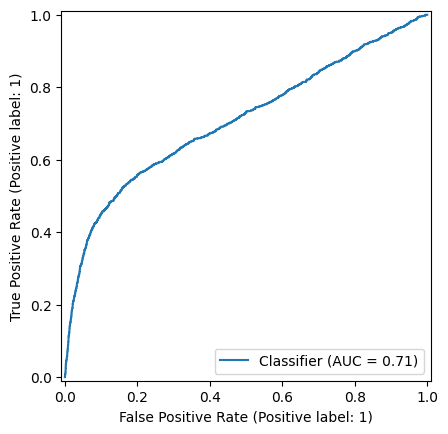

In [38]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, y_proba)


In [39]:
import pandas as pd
from sklearn.metrics import roc_auc_score, recall_score, precision_score

def audit_by_group(df, X_test, y_test, y_proba, group_col):
    results = []
    temp = X_test.copy()
    temp["DEFAULT"] = y_test.values
    temp["proba"] = y_proba

    for group in temp[group_col].dropna().unique():
        subset = temp[temp[group_col] == group]
        if len(subset) < 200:
            continue

        y_true = subset["DEFAULT"]
        y_score = subset["proba"]
        y_pred = (y_score >= 0.5).astype(int)

        results.append({
            "group": group,
            "n": len(subset),
            "default_rate": y_true.mean(),
            "auc": roc_auc_score(y_true, y_score),
            "precision": precision_score(y_true, y_pred),
            "recall": recall_score(y_true, y_pred),
        })

    return pd.DataFrame(results)

audit_age = audit_by_group(df, X_test, y_test, y_proba, "AGE_BIN")
audit_age


,group,n,default_rate,auc,precision,recall
0,40-49,1341,0.232662,0.699599,0.686957,0.253205
1,30-39,2198,0.206096,0.710459,0.678082,0.218543
2,21-29,1912,0.223326,0.715010,0.710345,0.241218
3,50+,549,0.245902,0.686348,0.677966,0.296296


In [40]:
import numpy as np
from sklearn.metrics import roc_auc_score

X_test_stress = X_test.copy()

# aplica ruído leve (5%) só nas colunas numéricas
for col in num_cols:
    noise = np.random.normal(0, 0.05 * X_test_stress[col].std(), size=len(X_test_stress))
    X_test_stress[col] = X_test_stress[col] + noise


In [41]:
y_proba_stress = baseline.predict_proba(X_test_stress)[:, 1]
auc_stress = roc_auc_score(y_test, y_proba_stress)

print("AUC original:", round(auc, 4))
print("AUC com stress:", round(auc_stress, 4))
print("Queda:", round(auc - auc_stress, 4))


AUC original: 0.7078
AUC com stress: 0.7073
Queda: 0.0005
